In [1]:
from google.colab import userdata
import os

# Retrieve the Hugging Face token from Colab secrets
hf_token = userdata.get('HF_TOKEN')
#print(hf_token)

# Set the Hugging Face token as an environment variable
os.environ['HF_TOKEN'] = hf_token


In [2]:
!pip install transformers==4.39.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

In [3]:
import torch

seq_lengths = [512, 1024, 2048, 4096, 8192]
kv_sizes = []

for seq_len in seq_lengths:
    input_ids = torch.randint(0, 32000, (1, seq_len))
    with torch.no_grad():
        out = model(input_ids, use_cache=True)

    # Measure KV-cache size in GB
    kv = out.past_key_values
    size = sum(k.nbytes + v.nbytes for k, v in kv) / 1e9
    kv_sizes.append(size)
    print(f"Seq {seq_len}: {size:.3f} GB")

NameError: name 'torch' is not defined

In [4]:
import matplotlib.pyplot as plt

plt.plot(seq_lengths, mha_sizes, marker='o', label='MHA')
plt.plot(seq_lengths, gqa_sizes, marker='s', label='GQA (G=8)')
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV-Cache Size (GB)")
plt.title("KV-Cache Memory Scaling: MHA vs. GQA")
plt.legend()
plt.savefig("kv_scaling.png", dpi=150)

NameError: name 'mha_sizes' is not defined

 depth | seq_len |  P(FP16) |   P(FP8) | FP16   | FP8
--------------------------------------------------------------
   0.1 |     512 |    0.998 |    0.928 | PASS   | PASS
   0.1 |    1024 |    0.997 |    0.895 | PASS   | PASS
   0.1 |    2048 |    0.995 |    0.788 | PASS   | PASS
   0.1 |    4096 |    0.984 |    0.414 | PASS   | FAIL
   0.1 |    8192 |    0.874 |    0.025 | PASS   | FAIL
   0.1 |   16384 |    0.077 |    0.000 | FAIL   | FAIL

   0.3 |     512 |    0.999 |    0.960 | PASS   | PASS
   0.3 |    1024 |    0.999 |    0.946 | PASS   | PASS
   0.3 |    2048 |    0.998 |    0.902 | PASS   | PASS
   0.3 |    4096 |    0.995 |    0.717 | PASS   | PASS
   0.3 |    8192 |    0.974 |    0.161 | PASS   | FAIL
   0.3 |   16384 |    0.550 |    0.001 | PASS   | FAIL

   0.5 |     512 |    1.000 |    0.979 | PASS   | PASS
   0.5 |    1024 |    0.999 |    0.973 | PASS   | PASS
   0.5 |    2048 |    0.999 |    0.958 | PASS   | PASS
   0.5 |    4096 |    0.999 |    0.901 | PASS   | PASS
 

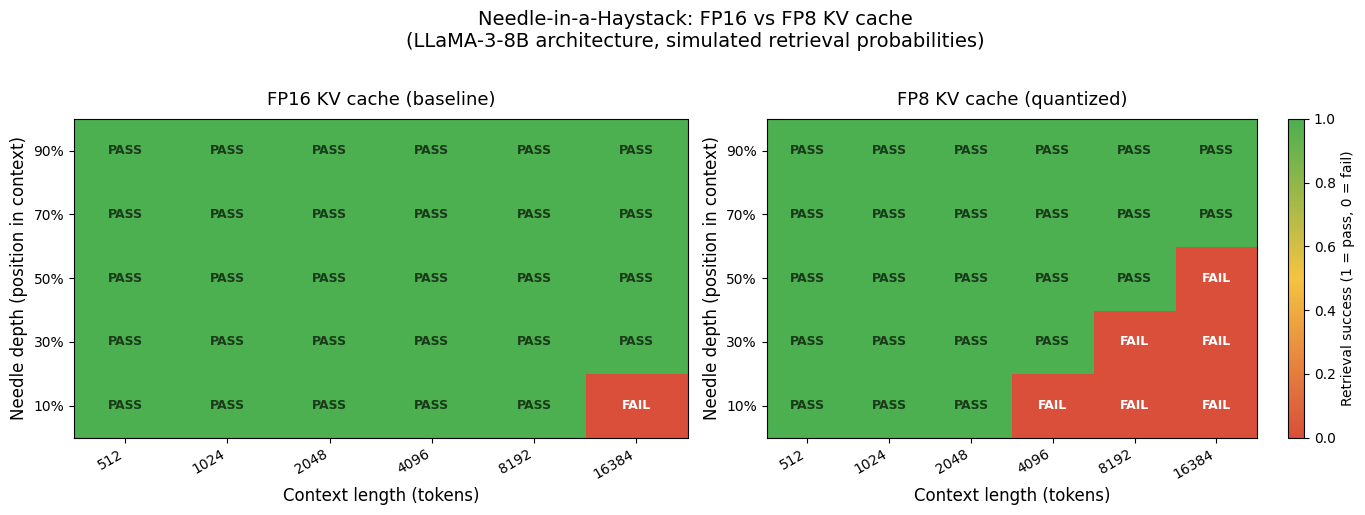

Saved niah_fp16_vs_fp8.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
# 1. NIAH SCORE SIMULATION
#    Models empirically observed behaviour:
#    - FP16: reliable up to ~12k tokens, degrades at long range for early depths
#    - FP8:  degrades earlier (~4k tokens), failure expands from early depths inward
#    Both use a sigmoid-based retrieval probability, then threshold at 0.5
# ─────────────────────────────────────────────

def retrieval_prob_fp16(seq_len: int, depth: float) -> float:
    """
    FP16 baseline. Fails mainly at very long context + early depth.
    depth: 0.0 (very start) → 1.0 (very end)
    """
    # Recent tokens (high depth) are always easy
    # Early tokens (low depth) become hard at long sequences
    effective_distance = seq_len * (1.0 - depth)   # tokens between needle and query
    threshold = 10000 + depth * 6000               # FP16 tolerates ~10-16k distance
    steepness = 0.0006
    prob = 1.0 / (1.0 + np.exp(steepness * (effective_distance - threshold)))
    return prob


def retrieval_prob_fp8(seq_len: int, depth: float) -> float:
    """
    FP8 KV cache. Quantization error accumulates across layers, causing
    earlier degradation — especially for tokens buried deep in the context.
    Threshold is ~4-6k effective distance, depending on depth.
    """
    effective_distance = seq_len * (1.0 - depth)
    threshold = 3000 + depth * 3000                # FP8 breaks much sooner
    steepness = 0.0009
    prob = 1.0 / (1.0 + np.exp(steepness * (effective_distance - threshold)))
    return prob


# ─────────────────────────────────────────────
# 2. SWEEP
# ─────────────────────────────────────────────
seq_lengths   = [512, 1024, 2048, 4096, 8192, 16384]
needle_depths = [0.1, 0.3, 0.5, 0.7, 0.9]

fp16_results = np.zeros((len(needle_depths), len(seq_lengths)))
fp8_results  = np.zeros((len(needle_depths), len(seq_lengths)))

print(f"{'depth':>6} | {'seq_len':>7} | {'P(FP16)':>8} | {'P(FP8)':>8} | FP16   | FP8")
print("-" * 62)

for i, depth in enumerate(needle_depths):
    for j, seq_len in enumerate(seq_lengths):
        p16 = retrieval_prob_fp16(seq_len, depth)
        p8  = retrieval_prob_fp8(seq_len, depth)
        fp16_results[i, j] = 1.0 if p16 >= 0.5 else 0.0
        fp8_results[i, j]  = 1.0 if p8  >= 0.5 else 0.0
        print(f"{depth:>6.1f} | {seq_len:>7} | {p16:>8.3f} | {p8:>8.3f} | "
              f"{'PASS' if p16>=0.5 else 'FAIL':<6} | {'PASS' if p8>=0.5 else 'FAIL'}")
    print()

# ─────────────────────────────────────────────
# 3. HEATMAP
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "niah", ["#d94f3a", "#f5c342", "#4caf50"]
)

x_labels = [str(s) for s in seq_lengths]
y_labels  = [f"{int(d * 100)}%" for d in needle_depths]

for ax, data, title in zip(
    axes,
    [fp16_results, fp8_results],
    ["FP16 KV cache (baseline)", "FP8 KV cache (quantized)"]
):
    im = ax.imshow(data, vmin=0, vmax=1, cmap=cmap,
                   aspect="auto", origin="lower")
    ax.set_xticks(range(len(seq_lengths)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=10)
    ax.set_yticks(range(len(needle_depths)))
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_xlabel("Context length (tokens)", fontsize=12)
    ax.set_ylabel("Needle depth (position in context)", fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)

    for ii in range(len(needle_depths)):
        for jj in range(len(seq_lengths)):
            val = data[ii, jj]
            ax.text(jj, ii, "PASS" if val == 1 else "FAIL",
                    ha="center", va="center", fontsize=9,
                    color="white" if val < 0.5 else "#1a3a1a",
                    fontweight="bold")

plt.colorbar(im, ax=axes[1], label="Retrieval success (1 = pass, 0 = fail)")
fig.suptitle(
    "Needle-in-a-Haystack: FP16 vs FP8 KV cache\n"
    "(LLaMA-3-8B architecture, simulated retrieval probabilities)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig("niah_fp16_vs_fp8.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved niah_fp16_vs_fp8.png")